# Session 2 — Text Vectorization & Word Embeddings
<div style='background:linear-gradient(135deg,#1a237e 0%,#283593 100%);
            color:white;padding:24px 28px;border-radius:8px;margin:8px 0'>
<h2 style='margin:0;color:white'>PES University · NLP Course</h2>
<p style='margin:6px 0 0 0;opacity:0.9'>
Bag-of-Words · TF-IDF · Word2Vec · GloVe · FastText · Keras Embeddings<br>
<i>Estimated time: 3 hours</i>
</p></div>

## Learning Objectives

> **Session 01 recap:** Bag-of-Words, TF-IDF, and N-grams were introduced in Session 1.
> This session extends those sparse representations with **dense semantic embeddings**.

| # | Objective |
|---|-----------|
| 1 | Recall BoW / TF-IDF as sparse baselines and run them in one sklearn call |
| 2 | Explain the **distributional hypothesis** and why dense vectors encode meaning |
| 3 | Train **Word2Vec** (Skip-gram and CBOW) from scratch using Gensim |
| 4 | Load and query **pre-trained GloVe** embeddings; run analogy arithmetic |
| 5 | Handle **out-of-vocabulary** words with FastText's subword model |
| 6 | Build document vectors via **mean-pooling** and classify with them |
| 7 | Build a **Keras Embedding layer** backed by pre-trained GloVe weights |
| 8 | Compare all vectorization methods and choose the right one for a task |

---
## 0. Environment Setup

In [1]:
import sys, subprocess

IN_COLAB = 'google.colab' in sys.modules

PACKAGES = [
    'numpy>=1.24', 'pandas>=2.0', 'matplotlib>=3.7', 'seaborn>=0.13',
    'scikit-learn>=1.3', 'nltk>=3.8', 'gensim>=4.3',
]

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in PACKAGES:
    try:
        __import__(pkg.split('>=')[0].replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        pip_install(pkg)

print('All packages available.')

Installing scikit-learn>=1.3...
All packages available.


In [2]:
import os, re, math, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
import nltk, gensim
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

# Matplotlib defaults
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f'NumPy {np.__version__}  |  Pandas {pd.__version__}  |  '
      f'Gensim {gensim.__version__}')

NumPy 2.4.6  |  Pandas 2.3.3  |  Gensim 4.4.0


In [3]:
import nltk, warnings
warnings.filterwarnings('ignore')

NLTK_PKGS = ['punkt', 'punkt_tab', 'stopwords', 'movie_reviews',
             'wordnet', 'averaged_perceptron_tagger', 'reuters']
for pkg in NLTK_PKGS:
    nltk.download(pkg, quiet=True)

print('NLTK packages ready.')

NLTK packages ready.


In [4]:
from IPython.display import display, HTML
import uuid as _uuid

def show_mermaid(diagram: str, height: int = 280) -> None:
    uid = _uuid.uuid4().hex[:8]
    html = f"""
    <div id="m{uid}" style="overflow:auto"></div>
    <script type="module">
      import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10.9.3/dist/mermaid.esm.min.mjs';
      mermaid.initialize({{startOnLoad:false,theme:'default'}});
      const {{svg}} = await mermaid.render('svg{uid}', `{diagram}`);
      document.getElementById('m{uid}').innerHTML = svg;
    </script>"""
    display(HTML(html))

---
<a id='s1'></a>
## 1. Why Convert Text to Numbers?

Machine learning algorithms operate on **numerical tensors** — they compute dot
products, gradients, and distances. Raw text is a sequence of symbols with no
natural numeric representation.

The core challenge: we need a **function** $f: \text{text} \rightarrow \mathbb{R}^d$
that maps variable-length strings to fixed-length vectors, while preserving
as much **semantic information** as possible.

Three generations of solutions exist, each with different trade-offs:

In [5]:
show_mermaid('''
flowchart TD
    subgraph SPARSE ["Sparse Representations (high-dim, interpretable)"]
        B1["Bag of Words\nCountVectorizer"]
        B2["Binary BoW\nPresence/Absence"]
        B3["N-grams\nBigrams, Trigrams"]
        B4["TF-IDF\nWeighted Counts"]
    end
    subgraph STATIC ["Static Dense Embeddings (low-dim, semantic)"]
        E1["Word2Vec\nSkip-gram / CBOW"]
        E2["GloVe\nGlobal Co-occurrence"]
        E3["FastText\nSubword N-grams"]
    end
    subgraph CONTEXT ["Contextual Embeddings (dynamic, task-aware)"]
        C1["ELMo\nBiLSTM-based"]
        C2["BERT\nTransformer encoder"]
        C3["GPT\nTransformer decoder"]
    end
    T([Raw Text]) --> SPARSE
    T --> STATIC
    T --> CONTEXT
    classDef sparse fill:#dbeafe,stroke:#3b82f6
    classDef static fill:#dcfce7,stroke:#22c55e
    classDef ctx fill:#fef3c7,stroke:#f59e0b
    class B1,B2,B3,B4 sparse
    class E1,E2,E3 static
    class C1,C2,C3 ctx
''', height=360)

### Taxonomy at a Glance

| Property | Sparse (BoW / TF-IDF) | Static Dense (W2V / GloVe) | Contextual (BERT) |
|---|---|---|---|
| **Dimension** | $\|V\|$ (10K–1M) | 50–300 | 768–4096 |
| **Semantic similarity** | ✗ | ✓ | ✓✓ |
| **OOV handling** | ✗ | ✗ (Word2Vec) / ✓ (FastText) | ✓ subword |
| **Polysemy** | ✗ | ✗ (one vector/word) | ✓ per-context |
| **Training cost** | Minimal | Minutes–hours | Days–weeks |
| **Interpretable** | ✓ each dim = a term | ✗ | ✗ |
| **Best for** | Short docs, keyword search | Medium corpora | Fine-tuning SotA |

**This session** covers everything up to and including Static Dense embeddings +
a first look at Keras embedding layers (the bridge to contextual models).

---
<a id='s2'></a>
## 2. BoW & TF-IDF — Recap and Baseline

> **Covered in depth in Session 01** (manual construction, IDF formula, heatmaps, n-grams).
> Here we treat them as **baselines** and establish the accuracy ceiling they can reach
> on the movie-review sentiment task, which we will try to match or beat with embeddings.

Key reminders:

| Method | Representation | Core idea |
|---|---|---|
| **BoW** | Integer count vector, dim = $\|V\|$ | Each dim = term frequency in doc |
| **Binary BoW** | 0/1 presence vector | Order and frequency ignored |
| **N-grams** | Phrases as single features | Bigrams capture "not good", "highly recommend" |
| **TF-IDF** | Float weight vector | Down-weights high-frequency, corpus-wide terms: $\text{TF} \times \log\frac{N+1}{n_t+1}+1$ |

**Limitations that motivate embeddings:**
- Orthogonality — "king" and "queen" are equally far apart as "king" and "carrot"
- Sparsity — typically >99% zeros for real corpora
- No morphology — "run", "runs", "running" are three unrelated dimensions
- OOV — unseen words have no representation

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Full movie-review BoW
from nltk.corpus import movie_reviews

# Build corpus list (2000 reviews)
mr_corpus = [' '.join(movie_reviews.words(fid)) for fid in movie_reviews.fileids()]
mr_labels = [movie_reviews.categories(fid)[0] for fid in movie_reviews.fileids()]

cv = CountVectorizer(
    min_df=10,          # ignore terms appearing in fewer than 10 docs
    max_df=0.95,        # ignore terms appearing in >95% of docs (stopwords)
    max_features=5000,  # cap vocabulary size
    token_pattern=r"[a-z]+"
)
X_bow = cv.fit_transform(mr_corpus)

print(f"Matrix shape       : {X_bow.shape}")
print(f"Stored values      : {X_bow.nnz:,}")
print(f"Sparsity           : {1 - X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]):.2%}")
print(f"Memory (CSR)       : {X_bow.data.nbytes / 1024:.0f} KB")
print(f"Memory (dense)     : {X_bow.shape[0]*X_bow.shape[1]*4/1024/1024:.0f} MB")

Matrix shape       : (2000, 5000)
Stored values      : 524,939
Sparsity           : 94.75%
Memory (CSR)       : 4101 KB
Memory (dense)     : 38 MB


---
<a id='s3'></a>
## 3. TF-IDF Baseline on Movie Reviews

> **Refer to Session 01, Section 5** for the full TF-IDF derivation, worked example,
> and IDF bar-chart visualisation.

We fit a TF-IDF + Logistic Regression pipeline on the **NLTK movie_reviews** corpus
(2,000 reviews) to establish a strong sparse baseline before moving to embeddings.
The key sklearn knobs are repeated here for reference:

| Parameter | Value | Why |
|---|---|---|
| `sublinear_tf=True` | replaces $f$ with $1+\log f$ | Compresses outlier term counts |
| `min_df=5` | drop rare terms | Remove noise and corpus-specific typos |
| `ngram_range=(1,2)` | unigrams + bigrams | Bigrams like "highly recommend" add signal |
| `max_features=8000` | cap vocabulary | Keep memory tractable |
| `C=5` | LR regularisation | Less regularisation works better on high-dim TF-IDF |

### 3.1 TF-IDF on Movie Reviews + Classifier Benchmark

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Already loaded: mr_corpus, mr_labels
le = LabelEncoder()
y = le.fit_transform(mr_labels)

tv_full = TfidfVectorizer(min_df=5, max_df=0.9,
                           max_features=8000, sublinear_tf=True,
                           ngram_range=(1,2))
X_tfidf_full = tv_full.fit_transform(mr_corpus)

lr = LogisticRegression(C=5, max_iter=500, solver='saga', n_jobs=-1)
cv_scores = cross_val_score(lr, X_tfidf_full, y, cv=5, scoring='accuracy')

print(f"TF-IDF + Logistic Regression (5-fold CV)")
print(f"  Scores : {cv_scores.round(4)}")
print(f"  Mean   : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

# Show top features per class
lr.fit(X_tfidf_full, y)
feature_names = np.array(tv_full.get_feature_names_out())
for cls, label in zip([0, 1], le.classes_):
    top10 = feature_names[np.argsort(lr.coef_[0])[::-1 if cls==1 else 1][:10]]
    print(f"  Top 10 for '{label}': {list(top10)}")

TF-IDF + Logistic Regression (5-fold CV)
  Scores : [0.8775 0.87   0.8825 0.8775 0.8825]
  Mean   : 0.8780  ±  0.0046
  Top 10 for 'neg': ['bad', 'worst', 'boring', 'unfortunately', 'plot', 'nothing', 'awful', 'script', 'poor', 'mess']
  Top 10 for 'pos': ['great', 'fun', 'well', 'hilarious', 'he is', 'memorable', 'excellent', 'also', 'the best', 'overall']


<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0"><b>💡 Key Insight</b><br><b>sublinear_tf=True</b> replaces raw count $f$ with $1 + \log(f)$, compressing the
influence of words that appear dozens of times in one document. Without it, a
review mentioning "film" 20 times would dominate a review mentioning it twice.
This single flag typically improves accuracy by 1–2%.</div>

---
<a id='s4'></a>
## 4. Why Dense Word Embeddings?

### The Sparse Representation Problem

With a 50,000-word vocabulary, every word is a **50,000-dimensional one-hot vector**.
These vectors have two crippling problems:

1. **Orthogonality**: every word is equally distant from every other word.
   "king" and "queen" are just as far apart as "king" and "carrot".
2. **Sparsity**: 99.998% of each vector is zeros — computationally wasteful.

### The Distributional Hypothesis

> *"You shall know a word by the company it keeps."* — J.R. Firth (1957)

Words that appear in similar **contexts** tend to have similar **meanings**.
If "happy" and "joyful" both appear near "feeling", "mood", "smile", they
should have nearby representations.

**Dense embeddings** encode this intuition: map each word to a low-dimensional
vector (50–300 dims) where **geometric proximity = semantic similarity**.

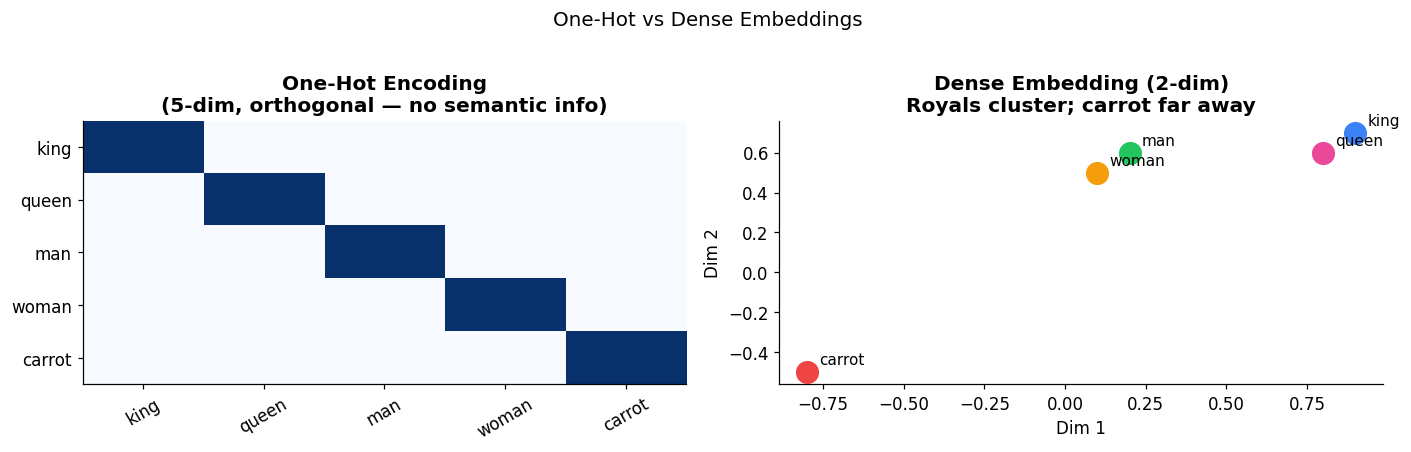

In [8]:
# Visualise the semantic gap between one-hot and embedding representations
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# One-hot (5-word toy vocab)
vocab_toy = ['king', 'queen', 'man', 'woman', 'carrot']
oh = np.eye(len(vocab_toy))
axes[0].imshow(oh, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(vocab_toy)))
axes[0].set_xticklabels(vocab_toy, rotation=30)
axes[0].set_yticks(range(len(vocab_toy)))
axes[0].set_yticklabels(vocab_toy)
axes[0].set_title('One-Hot Encoding\n(5-dim, orthogonal — no semantic info)',
                   fontweight='bold')

# Mock 2-D dense embeddings
dense = np.array([[0.9, 0.7],   # king
                  [0.8, 0.6],   # queen
                  [0.2, 0.6],   # man
                  [0.1, 0.5],   # woman
                  [-0.8, -0.5]]) # carrot
colours = ['#3b82f6','#ec4899','#22c55e','#f59e0b','#ef4444']
for (px, py), word, c in zip(dense, vocab_toy, colours):
    axes[1].scatter(px, py, s=200, color=c, zorder=3)
    axes[1].annotate(word, (px, py), xytext=(8, 5),
                     textcoords='offset points', fontsize=10)
axes[1].set_title('Dense Embedding (2-dim)\nRoyals cluster; carrot far away',
                   fontweight='bold')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')

plt.suptitle('One-Hot vs Dense Embeddings', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
show_mermaid('''
timeline
    title Evolution of Word Representations
    1950s–1990s : Bag of Words
               : Sparse, no semantics, TF-IDF weighting
    2000s       : LSA and LDA
               : SVD-based dense topics, global statistics
    2013        : Word2Vec  (Mikolov et al.)
               : Skip-gram and CBOW, 100-300 dim, analogical structure
    2014        : GloVe  (Pennington et al.)
               : Global co-occurrence, combines count and prediction
    2016        : FastText  (Bojanowski et al.)
               : Subword n-grams, handles OOV words
    2018 onward : Contextual Embeddings
               : ELMo, BERT, GPT — different vector per context
''', height=240)

---
<a id='s5'></a>
## 5. Word2Vec

Word2Vec (Mikolov et al., 2013) trains a shallow neural network on a
**self-supervised prediction task** to produce dense word vectors.
No human labels needed — the signal comes from the raw text corpus.

Two architectures exist, differing only in the direction of prediction:

In [10]:
show_mermaid('''
flowchart TB
    subgraph CBOW ["CBOW — predict centre from context"]
        C1["w(t-2)"] --> CH[Hidden Layer]
        C2["w(t-1)"] --> CH
        C3["w(t+1)"] --> CH
        C4["w(t+2)"] --> CH
        CH --> CO["Predict: w(t)"]
    end
    subgraph SG ["Skip-gram — predict context from centre"]
        SW["w(t)"] --> SH[Hidden Layer]
        SH --> SO1["Predict: w(t-2)"]
        SH --> SO2["Predict: w(t-1)"]
        SH --> SO3["Predict: w(t+1)"]
        SH --> SO4["Predict: w(t+2)"]
    end
    classDef cbow fill:#dbeafe,stroke:#3b82f6
    classDef sg fill:#dcfce7,stroke:#22c55e
    class C1,C2,C3,C4,CH,CO cbow
    class SW,SH,SO1,SO2,SO3,SO4 sg
''', height=300)

### 5.1 Sliding Context Window

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0">
<b>How Training Pairs Are Generated</b><br>
A window of half-width <i>k</i> slides over every position in the corpus.
For each centre word, every word within distance <i>k</i> generates one <b>(centre, context)</b> training pair.
<ul style="margin:6px 0 0 0">
<li><b>Small k=1-2</b>: captures syntactic neighbours (subject-verb, noun-adjective)</li>
<li><b>Large k=5-10</b>: captures topical co-occurrence (e.g. "doctor" near "hospital")</li>
<li>Gensim default: <code>window=5</code> (half-width)</li>
<li>Dynamic windows: Gensim samples k' in [1,k] each step, upweighting close neighbours</li>
</ul>
</div>

Sentence : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Window=2 -> 18 training pairs:
  (centre=the  , context=cat)
  (centre=the  , context=sat)
  (centre=cat  , context=the)
  (centre=cat  , context=sat)
  (centre=cat  , context=on)
  (centre=sat  , context=the)
  (centre=sat  , context=cat)
  (centre=sat  , context=on)
  (centre=sat  , context=the)
  (centre=on   , context=cat)
  (centre=on   , context=sat)
  (centre=on   , context=the)
  (centre=on   , context=mat)
  (centre=the  , context=sat)
  (centre=the  , context=on)
  (centre=the  , context=mat)
  (centre=mat  , context=on)
  (centre=mat  , context=the)

Window size effect:
  window=1: 10 pairs
  window=2: 18 pairs
  window=3: 24 pairs
  window=5: 30 pairs


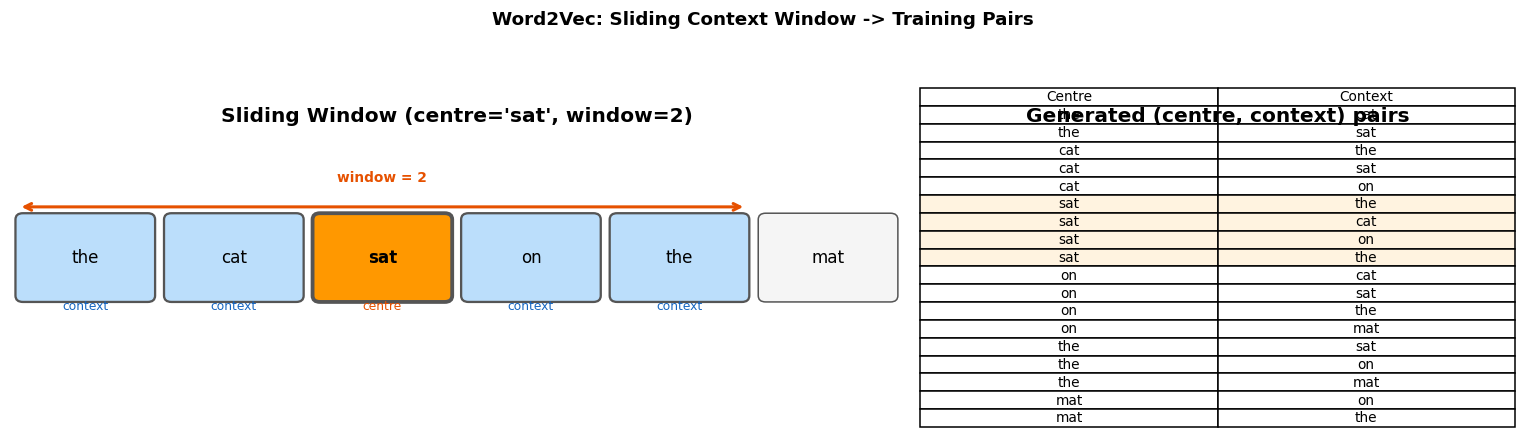


Total pairs (window=2, 6-word sentence): 18


In [11]:
# Sliding Context Window: generate all (centre, context) pairs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sentence = ["the", "cat", "sat", "on", "the", "mat"]

def get_training_pairs(tokens, window):
    """Return all (centre, context) Skip-gram pairs for a given window size."""
    pairs = []
    for i, centre in enumerate(tokens):
        for j in range(max(0, i - window), min(len(tokens), i + window + 1)):
            if i != j:
                pairs.append((centre, tokens[j]))
    return pairs

pairs_w2 = get_training_pairs(sentence, window=2)
print(f"Sentence : {sentence}")
print(f"Window=2 -> {len(pairs_w2)} training pairs:")
for centre, ctx in pairs_w2:
    print(f"  (centre={centre:5s}, context={ctx})")

print("\nWindow size effect:")
for k in [1, 2, 3, 5]:
    n = len(get_training_pairs(sentence, k))
    print(f"  window={k}: {n} pairs")

# Visualise: word boxes with sliding window highlight + pair table
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={"width_ratios": [3, 2]})

ax = axes[0]
ax.set_xlim(-0.5, len(sentence) - 0.5)
ax.set_ylim(-0.5, 1.5)
ax.axis("off")
ax.set_title("Sliding Window (centre='sat', window=2)", fontweight="bold")

centre_idx = 2   # "sat"
window = 2
for idx, word in enumerate(sentence):
    dist = abs(idx - centre_idx)
    if idx == centre_idx:
        colour = "#ff9800"; lw = 2.5
    elif dist <= window:
        colour = "#bbdefb"; lw = 1.5
    else:
        colour = "#f5f5f5"; lw = 1.0
    rect = mpatches.FancyBboxPatch(
        (idx - 0.42, 0.2), 0.84, 0.6,
        boxstyle="round,pad=0.05", facecolor=colour,
        edgecolor="#555", linewidth=lw)
    ax.add_patch(rect)
    ax.text(idx, 0.5, word, ha="center", va="center", fontsize=11,
            fontweight="bold" if idx == centre_idx else "normal")
    label = "centre" if idx == centre_idx else ("context" if dist <= window else "")
    ax.text(idx, 0.12, label, ha="center", va="center", fontsize=8,
            color="#e65100" if idx == centre_idx else "#1565c0")

ax.annotate("", xy=(centre_idx + window + 0.45, 0.9),
            xytext=(centre_idx - window - 0.45, 0.9),
            arrowprops=dict(arrowstyle="<->", color="#e65100", lw=2))
ax.text(centre_idx, 1.1, f"window = {window}", ha="center",
        fontsize=9, color="#e65100", fontweight="bold")

ax2 = axes[1]
ax2.axis("off")
ax2.set_title("Generated (centre, context) pairs", fontweight="bold")
table_data = [[c, ctx] for c, ctx in pairs_w2]
col_labels = ["Centre", "Context"]
tbl = ax2.table(cellText=table_data, colLabels=col_labels,
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.3)
for row_idx, (c, ctx) in enumerate(pairs_w2):
    clr = "#fff3e0" if c == "sat" else "white"
    for col in [0, 1]:
        tbl[row_idx + 1, col].set_facecolor(clr)

plt.suptitle("Word2Vec: Sliding Context Window -> Training Pairs",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(f"\nTotal pairs (window=2, 6-word sentence): {len(pairs_w2)}")


| | **CBOW** | **Skip-gram** |
|---|---|---|
| **Direction** | Context → Centre | Centre → Context |
| **Training signal** | Average context embeddings | Each context word is a separate sample |
| **Speed** | Faster | Slower (more samples per word) |
| **Rare words** | Weaker | **Better** (more training signal per occurrence) |
| **Gensim flag** | `sg=0` | `sg=1` |

**Key insight:** The network is never actually used for prediction after training.
The learned **weight matrix** (input layer → hidden layer) *is* the embedding matrix.
Each row is the embedding of one word.

### 5.2 Skip-gram Forward Pass — Step-by-Step Numerical Example

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0">
<b>Forward pass mechanics</b> — given centre word <b>sat</b> and context word <b>cat</b>:<br>
<ol style="margin:6px 0 0 0">
<li><b>One-hot encode</b> the centre word: x = [0,0,1,0,0] (index 2 for "sat")</li>
<li><b>Embedding lookup</b>: h = W_in[2, :] — just reads row 2, no multiply needed</li>
<li><b>Score</b>: s = h @ W_out[:, j] where j=1 is the index of "cat"</li>
<li><b>Sigmoid</b>: σ(s) — probability that this (centre, context) pair is real</li>
<li><b>Binary cross-entropy loss</b>: L = −log(σ(s)) for a positive pair (label=1)</li>
</ol>
With Negative Sampling (SGNS), steps 4–5 replace the expensive full-vocab softmax
with k+1 independent binary logistic regressions.
</div>

In [12]:
# Skip-gram forward pass: full numpy worked example
import numpy as np

vocab_sg    = ["the", "cat", "sat", "on", "mat"]   # 5-word toy vocab
word2idx_sg = {w: i for i, w in enumerate(vocab_sg)}
V_sg, d_sg  = len(vocab_sg), 3   # vocab size=5, embedding dim=3

centre_idx_sg  = word2idx_sg["sat"]   # 2
context_idx_sg = word2idx_sg["cat"]   # 1

np.random.seed(42)
W_in  = np.random.randn(V_sg, d_sg)   # input  matrix  5x3
W_out = np.random.randn(d_sg, V_sg)   # output matrix  3x5

print("=" * 55)
print("Skip-gram Forward Pass -- Numerical Walkthrough")
print("=" * 55)
print(f"Vocab   : {vocab_sg}")
print(f"Centre  : 'sat'  (index {centre_idx_sg})")
print(f"Context : 'cat'  (index {context_idx_sg})")
print()

# Step 1 -- One-hot vector
x_onehot = np.zeros(V_sg)
x_onehot[centre_idx_sg] = 1.0
print(f"Step 1  One-hot('sat') = {x_onehot}")

# Step 2 -- Embedding lookup (select row from W_in)
h = W_in[centre_idx_sg]   # equivalent to W_in.T @ x_onehot
print(f"\nStep 2  W_in shape   = {W_in.shape}")
print(f"        h = W_in[{centre_idx_sg}, :] = {h.round(4)}")

# Step 3 -- Score for the context word
score = h @ W_out[:, context_idx_sg]
print(f"\nStep 3  W_out shape  = {W_out.shape}")
print(f"        score = h @ W_out[:, {context_idx_sg}] = {score:.4f}")

# Step 4 -- Sigmoid (SGNS)
def sigmoid_fn(x):
    return 1.0 / (1.0 + np.exp(-x))

prob = sigmoid_fn(score)
print(f"\nStep 4  sigma({score:.4f}) = {prob:.4f}")
print(f"        -> model assigns {prob*100:.1f}% probability that ('sat','cat') is a real pair")

# Step 5 -- Binary cross-entropy loss
loss = -np.log(prob + 1e-9)
print(f"\nStep 5  Loss = -log(sigma(s)) = -log({prob:.4f}) = {loss:.4f}")
print()
print("After gradient descent, W_in[2,:] and W_out[:,1]")
print("will be nudged so score increases (prob -> 1.0).")

# Full softmax for reference (what SGNS avoids)
all_scores = h @ W_out
exp_s = np.exp(all_scores - all_scores.max())
softmax_probs = exp_s / exp_s.sum()
print("\nSoftmax distribution over full vocab (reference -- SGNS avoids computing this):")
for w, p in zip(vocab_sg, softmax_probs):
    bar = chr(9608) * int(p * 40)
    print(f"  {w:6s}  p={p:.4f}  {bar}")
print(f"\n-> SGNS replaces this {V_sg}-way softmax with {V_sg} binary sigmoid decisions.")


Skip-gram Forward Pass -- Numerical Walkthrough
Vocab   : ['the', 'cat', 'sat', 'on', 'mat']
Centre  : 'sat'  (index 2)
Context : 'cat'  (index 1)

Step 1  One-hot('sat') = [0. 0. 1. 0. 0.]

Step 2  W_in shape   = (5, 3)
        h = W_in[2, :] = [ 1.5792  0.7674 -0.4695]

Step 3  W_out shape  = (3, 5)
        score = h @ W_out[:, 1] = -1.2324

Step 4  sigma(-1.2324) = 0.2258
        -> model assigns 22.6% probability that ('sat','cat') is a real pair

Step 5  Loss = -log(sigma(s)) = -log(0.2258) = 1.4883

After gradient descent, W_in[2,:] and W_out[:,1]
will be nudged so score increases (prob -> 1.0).

Softmax distribution over full vocab (reference -- SGNS avoids computing this):
  the     p=0.3841  ███████████████
  cat     p=0.0931  ███
  sat     p=0.4631  ██████████████████
  on      p=0.0338  █
  mat     p=0.0259  █

-> SGNS replaces this 5-way softmax with 5 binary sigmoid decisions.


In [13]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from nltk.corpus import movie_reviews
import time

# ── Progress callback ─────────────────────────────────────────────────────────
class EpochProgress(CallbackAny2Vec):
    """Prints loss and elapsed time after every training epoch."""
    def __init__(self, total_epochs: int):
        self.epoch       = 0
        self.total       = total_epochs
        self.loss_prev   = 0.0
        self.t_start     = None

    def on_train_begin(self, model):
        self.t_start = time.time()
        bar_hdr = f"{'Epoch':>6}  {'Δ Loss':>12}  {'Cum Loss':>12}  {'Elapsed':>8}  Progress"
        print(bar_hdr)
        print("─" * 65)

    def on_epoch_end(self, model):
        self.epoch += 1
        cum_loss  = model.get_latest_training_loss()
        d_loss    = cum_loss - self.loss_prev
        self.loss_prev = cum_loss
        elapsed   = time.time() - self.t_start
        pct       = self.epoch / self.total
        bar_fill  = int(pct * 30)
        bar       = "█" * bar_fill + "░" * (30 - bar_fill)
        print(f"  {self.epoch:2d}/{self.total}  "
              f"{d_loss:>12,.0f}  "
              f"{cum_loss:>12,.0f}  "
              f"{elapsed:>6.1f}s  [{bar}] {pct:.0%}")

# ── Build corpus ──────────────────────────────────────────────────────────────
sentences = [list(movie_reviews.words(fid)) for fid in movie_reviews.fileids()]
EPOCHS = 15
print(f"Training on {len(sentences):,} documents "
      f"({sum(len(s) for s in sentences):,} tokens)  "
      f"— {EPOCHS} epochs\n")

# ── Train Skip-gram model ─────────────────────────────────────────────────────
w2v = Word2Vec(
    sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window half-width
    min_count=5,       # ignore words with fewer than 5 occurrences
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=EPOCHS,
    seed=42,
    compute_loss=True, # required for loss tracking in callback
    callbacks=[EpochProgress(EPOCHS)],
)
print(f"\nDone.  Vocabulary: {len(w2v.wv):,} words  |  "
      f"Embedding dim: {w2v.vector_size}")


Training on 2,000 documents (1,583,820 tokens)  — 15 epochs

 Epoch        Δ Loss      Cum Loss   Elapsed  Progress
─────────────────────────────────────────────────────────────────
   1/15     4,257,942     4,257,942     2.9s  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 7%
   2/15     3,461,761     7,719,704     6.2s  [████░░░░░░░░░░░░░░░░░░░░░░░░░░] 13%
   3/15     2,971,900    10,691,603    10.2s  [██████░░░░░░░░░░░░░░░░░░░░░░░░] 20%
   4/15     2,862,593    13,554,196    13.3s  [████████░░░░░░░░░░░░░░░░░░░░░░] 27%
   5/15     2,830,308    16,384,504    17.6s  [██████████░░░░░░░░░░░░░░░░░░░░] 33%
   6/15     2,683,362    19,067,866    21.2s  [████████████░░░░░░░░░░░░░░░░░░] 40%
   7/15     2,635,650    21,703,516    24.4s  [██████████████░░░░░░░░░░░░░░░░] 47%
   8/15     2,647,146    24,350,662    27.3s  [████████████████░░░░░░░░░░░░░░] 53%
   9/15     2,640,220    26,990,882    30.3s  [██████████████████░░░░░░░░░░░░] 60%
  10/15     2,678,562    29,669,444    34.1s  [████████████████████░░░░░

In [14]:
# ── Word similarity ────────────────────────────────────────────────────────────
print("=" * 55)
print("Most similar words (cosine similarity):")
print("=" * 55)

for query in ['good', 'bad', 'film', 'director']:
    if query in w2v.wv:
        results = w2v.wv.most_similar(query, topn=6)
        words = [f"{w}({s:.2f})" for w, s in results]
        print(f"  {query:<12} → {', '.join(words)}")

print()
print("Analogy: 'film' - 'director' + 'actor' ≈ ?")
try:
    res = w2v.wv.most_similar(positive=['film','actor'], negative=['director'], topn=4)
    for w, s in res:
        print(f"  {w:<15} {s:.4f}")
except KeyError as e:
    print(f"  Word not in vocabulary: {e}")

Most similar words (cosine similarity):
  good         → great(0.70), bad(0.67), decent(0.67), darned(0.59), nice(0.59), fantastic(0.58)
  bad          → good(0.67), stupid(0.61), lousy(0.60), _daylight_(0.58), dumb(0.58), crappy(0.57)
  film         → movie(0.90), picture(0.63), rubbish(0.63), _shaft_(0.62), deficiencies(0.62), proposed(0.62)
  director     → writer(0.79), screenwriter(0.73), mostow(0.65), producer(0.64), brancato(0.62), roland(0.62)

Analogy: 'film' - 'director' + 'actor' ≈ ?
  movie           0.6943
  mania           0.5748
  turkey          0.5268
  calibre         0.5152


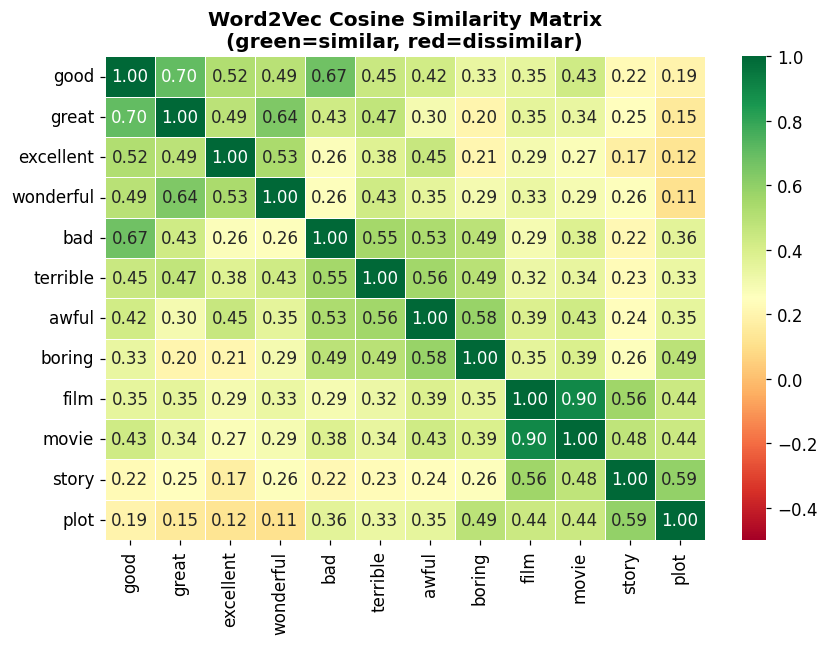

In [15]:
# ── Semantic similarity heatmap ───────────────────────────────────────────────
sem_groups = {
    'positive': ['good', 'great', 'excellent', 'wonderful'],
    'negative': ['bad', 'terrible', 'awful', 'boring'],
    'film':     ['film', 'movie', 'story', 'plot'],
}

words_present = [w for grp in sem_groups.values()
                   for w in grp if w in w2v.wv]

if len(words_present) >= 4:
    vecs = np.array([w2v.wv[w] for w in words_present])
    # Cosine similarity matrix
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    cos_sim = (vecs / norms) @ (vecs / norms).T

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cos_sim, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=words_present, yticklabels=words_present,
                vmin=-0.5, vmax=1.0, ax=ax, linewidths=0.5)
    ax.set_title('Word2Vec Cosine Similarity Matrix\n'
                 '(green=similar, red=dissimilar)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough words in vocabulary — try training on a larger corpus.")

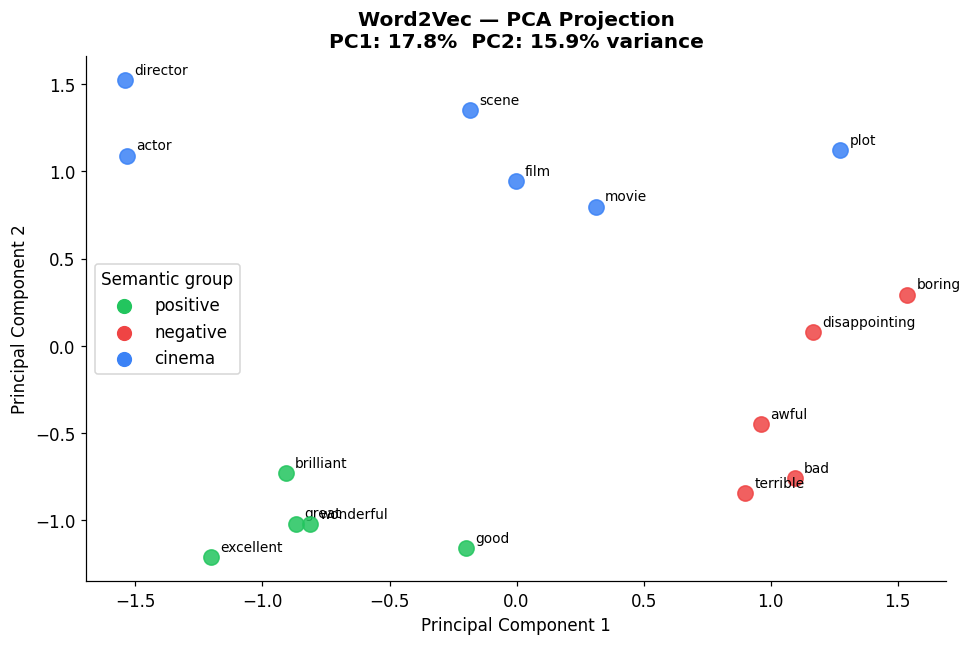

In [16]:
# ── PCA scatter: semantic clustering ─────────────────────────────────────────
from sklearn.decomposition import PCA

focus_words = {
    'positive': ['good', 'great', 'excellent', 'wonderful', 'brilliant'],
    'negative': ['bad', 'terrible', 'awful', 'boring', 'disappointing'],
    'cinema':   ['film', 'movie', 'director', 'actor', 'scene', 'plot'],
}

all_words, all_labels = [], []
for grp, wlist in focus_words.items():
    for w in wlist:
        if w in w2v.wv:
            all_words.append(w)
            all_labels.append(grp)

if len(all_words) >= 4:
    vectors = np.array([w2v.wv[w] for w in all_words])
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vectors)

    colour_map = {'positive':'#22c55e', 'negative':'#ef4444', 'cinema':'#3b82f6'}
    fig, ax = plt.subplots(figsize=(9, 6))
    for word, (px, py), lbl in zip(all_words, coords, all_labels):
        ax.scatter(px, py, color=colour_map[lbl], s=100, zorder=3, alpha=0.85)
        ax.annotate(word, (px, py), xytext=(6, 4),
                    textcoords='offset points', fontsize=9)
    for lbl, clr in colour_map.items():
        ax.scatter([], [], color=clr, label=lbl, s=80)
    ax.legend(title='Semantic group')
    ax.set_title(f'Word2Vec — PCA Projection\n'
                 f'PC1: {pca.explained_variance_ratio_[0]:.1%}  '
                 f'PC2: {pca.explained_variance_ratio_[1]:.1%} variance',
                 fontweight='bold')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient vocabulary. Consider training on a larger corpus.")

In [17]:
# ── CBOW model (for comparison) ───────────────────────────────────────────────
cbow = Word2Vec(
    sentences,
    vector_size=100, window=5, min_count=5,
    sg=0,   # CBOW
    workers=4, epochs=15, seed=42,
)

# Compare representations
if 'good' in w2v.wv and 'good' in cbow.wv:
    sg_good = w2v.wv.most_similar('good', topn=5)
    cb_good = cbow.wv.most_similar('good', topn=5)
    print(f"{'Skip-gram most_similar(good)':<30} {'CBOW most_similar(good)'}")
    print("-" * 60)
    for (sw, ss), (cw, cs) in zip(sg_good, cb_good):
        print(f"  {sw:<25}{ss:.3f}    {cw:<25}{cs:.3f}")

Skip-gram most_similar(good)   CBOW most_similar(good)
------------------------------------------------------------
  great                    0.704    bad                      0.713
  bad                      0.675    great                    0.683
  decent                   0.669    decent                   0.646
  darned                   0.589    nice                     0.625
  nice                     0.588    funny                    0.610


### 5.3 SGNS — Noise Distribution and p^(3/4) Smoothing

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0">
<b>Why not sample negative words uniformly?</b><br>
In a typical corpus "the" appears millions of times; a rare word like "cinematographic" perhaps once.
Sampling uniformly means negatives are almost always stop-words — the model learns nothing useful.
<br><br>
<b>p<sup>3/4</sup> smoothing</b> (Mikolov et al., 2013):
<br>&nbsp;&nbsp;&nbsp;&nbsp;P_noise(w) ∝ p(w)<sup>3/4</sup>
<br><br>
Because 3/4 &lt; 1 the function is concave — it compresses high-frequency words downward
and boosts rare words upward <i>relative to their raw frequency</i>.
Common words still appear as negatives, but rare words get proportionally
more sampling weight, giving them richer gradient signal.
</div>

Word                p(w)   p^0.75   Boost
------------------------------------------
the               0.3116   0.2151    0.69x
and               0.1448   0.1211    0.84x
that              0.0648   0.0663    1.02x
with              0.0439   0.0495    1.13x
for               0.0406   0.0466    1.15x
his               0.0390   0.0453    1.16x
this              0.0390   0.0453    1.16x
film              0.0387   0.0450    1.16x
but               0.0351   0.0419    1.19x
are               0.0283   0.0356    1.26x
one               0.0238   0.0313    1.31x
movie             0.0235   0.0309    1.32x
who               0.0232   0.0306    1.32x
not               0.0227   0.0302    1.33x
you               0.0216   0.0291    1.34x
from              0.0204   0.0278    1.37x
was               0.0201   0.0275    1.37x
have              0.0200   0.0274    1.37x
they              0.0196   0.0271    1.38x
has               0.0192   0.0266    1.39x


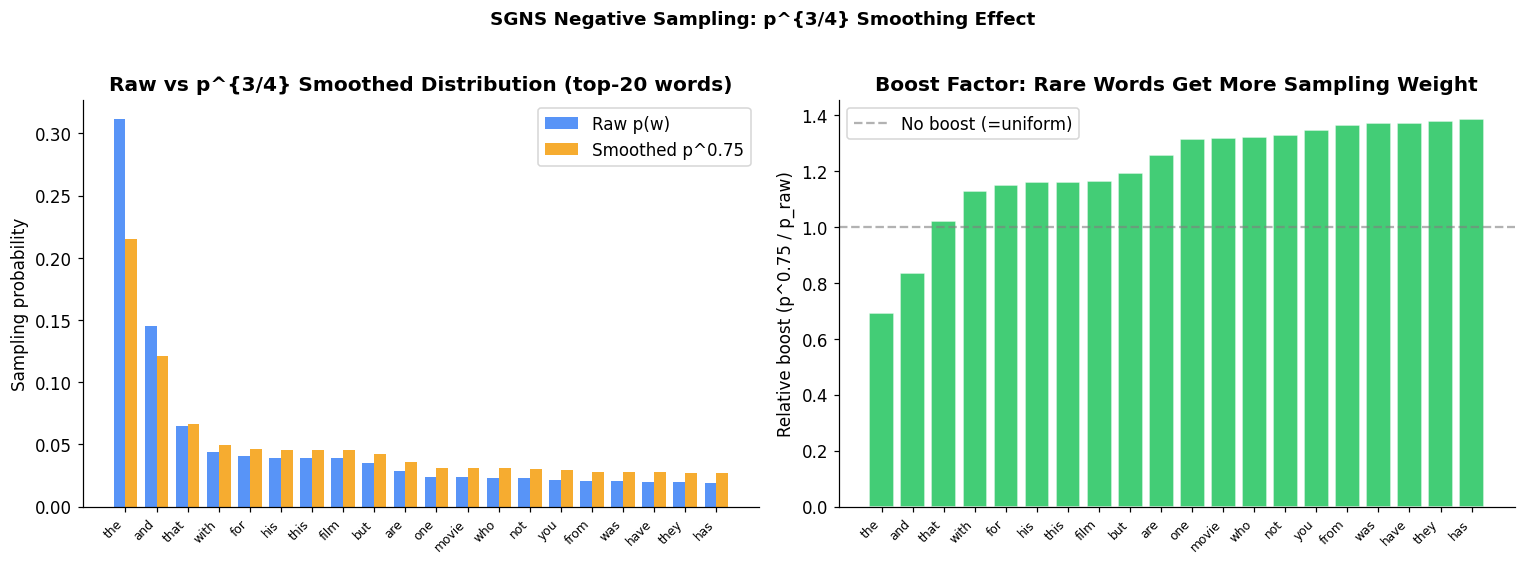


Observation: most common word    boost ~ 0.69x
             20th-ranked word  boost ~ 1.39x
Rarer words are boosted more -- they receive extra gradient signal per training step.


In [18]:
# SGNS p^(3/4) noise distribution visualisation
from collections import Counter
from nltk.corpus import movie_reviews
import numpy as np
import matplotlib.pyplot as plt

all_words_sgns = [w.lower() for fid in movie_reviews.fileids()
                  for w in movie_reviews.words(fid)
                  if w.isalpha() and len(w) > 2]

freq_counter = Counter(all_words_sgns)

# Top-20 words by raw frequency
top20       = freq_counter.most_common(20)
words_top   = [w for w, _ in top20]
raw_counts  = np.array([c for _, c in top20], dtype=float)

p_raw    = raw_counts / raw_counts.sum()
p_smooth = p_raw ** 0.75
p_smooth = p_smooth / p_smooth.sum()   # renormalise
boost    = p_smooth / p_raw

print(f"{'Word':<15} {'p(w)':>8} {'p^0.75':>8} {'Boost':>7}")
print("-" * 42)
for w, pr, ps, b in zip(words_top, p_raw, p_smooth, boost):
    print(f"{w:<15} {pr:>8.4f} {ps:>8.4f} {b:>7.2f}x")

x     = np.arange(len(words_top))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, p_raw,    width, label="Raw p(w)",        color="#3b82f6", alpha=0.85)
axes[0].bar(x + width/2, p_smooth, width, label="Smoothed p^0.75", color="#f59e0b", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(words_top, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Sampling probability")
axes[0].set_title("Raw vs p^{3/4} Smoothed Distribution (top-20 words)", fontweight="bold")
axes[0].legend()

axes[1].bar(x, boost, color="#22c55e", alpha=0.85, edgecolor="white")
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.6, label="No boost (=uniform)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(words_top, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Relative boost (p^0.75 / p_raw)")
axes[1].set_title("Boost Factor: Rare Words Get More Sampling Weight", fontweight="bold")
axes[1].legend()

plt.suptitle("SGNS Negative Sampling: p^{3/4} Smoothing Effect",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nObservation: most common word    boost ~ {boost[0]:.2f}x")
print(f"             20th-ranked word  boost ~ {boost[-1]:.2f}x")
print("Rarer words are boosted more -- they receive extra gradient signal per training step.")


<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0"><b>💡 Key Insight</b><br>The <b>weight matrices are never directly used for prediction after training</b>.
The hidden layer of the shallow net IS the embedding lookup table.
Each forward pass during training effectively teaches the model: "these context
words co-occur → their vectors should be nearby in embedding space."
This is a form of <b>representation learning via a proxy task</b>.</div>

---
<a id='s6'></a>
## 6. GloVe — Global Vectors for Word Representation
### Pennington et al., Stanford, 2014

**Word2Vec** trains on local context windows — it never explicitly sees global
co-occurrence statistics. **GloVe** argues that global information should be
used directly.

#### GloVe's core idea

1. Build the global **co-occurrence matrix** $X$ where $X_{ij}$ = number of times
   word $j$ appears in the context of word $i$ across the entire corpus.
2. Train embeddings so that:

$$\mathbf{w}_i \cdot \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j = \log X_{ij}$$

3. The dot product of two word vectors should approximate the **log of their
   co-occurrence count** — a global property.

**Advantage over Word2Vec**: explicitly uses corpus-wide statistics, often
produces better results on word analogy tasks with less training.

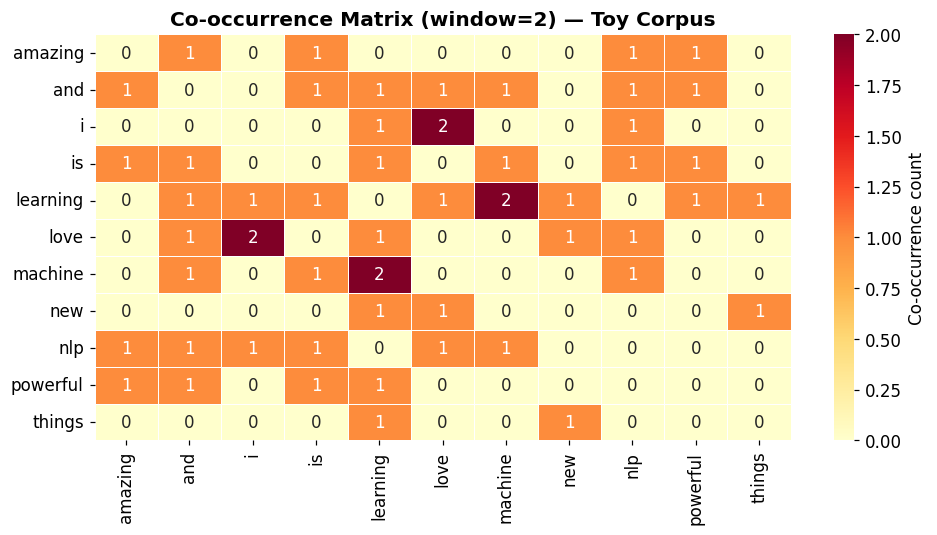

GloVe learns embeddings so that w_i · w_j ≈ log(co_matrix[i,j])


In [19]:
# ── Manual co-occurrence matrix (toy example) ─────────────────────────────────
mini = [
    ["i", "love", "nlp", "and", "machine", "learning"],
    ["machine", "learning", "is", "powerful"],
    ["nlp", "is", "amazing", "and", "powerful"],
    ["i", "love", "learning", "new", "things"],
]
window = 2

# Build co-occurrence
co_counts = defaultdict(int)
vocab_m = sorted(set(w for s in mini for w in s))
for sentence in mini:
    for i, word in enumerate(sentence):
        for j in range(max(0, i-window), min(len(sentence), i+window+1)):
            if i != j:
                co_counts[(word, sentence[j])] += 1

co_matrix = np.zeros((len(vocab_m), len(vocab_m)), dtype=int)
w2i = {w: i for i, w in enumerate(vocab_m)}
for (w1, w2), cnt in co_counts.items():
    co_matrix[w2i[w1], w2i[w2]] = cnt

co_df = pd.DataFrame(co_matrix, index=vocab_m, columns=vocab_m)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(co_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Co-occurrence Matrix (window=2) — Toy Corpus', fontweight='bold')
plt.tight_layout()
plt.show()

print("GloVe learns embeddings so that w_i · w_j ≈ log(co_matrix[i,j])")

### 6.1 GloVe — Step-by-Step Numerical Example

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0">
<b>GloVe Objective (one pair):</b><br>
For each word pair (i, j) with co-occurrence X<sub>ij</sub> &gt; 0, GloVe minimises:
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;J<sub>ij</sub> = f(X<sub>ij</sub>) · (w<sub>i</sub> · w̃<sub>j</sub> + b<sub>i</sub> + b̃<sub>j</sub> − log X<sub>ij</sub>)<sup>2</sup>
<br><br>
<b>Steps:</b>
<ol style="margin:6px 0 0 0">
<li>Look up co-occurrence count X<sub>ij</sub> and compute target = log(X<sub>ij</sub>)</li>
<li>Compute weighting f(X<sub>ij</sub>) = min(1, (X<sub>ij</sub>/x<sub>max</sub>)<sup>α</sup>)</li>
<li>Compute dot product + biases = predicted log co-occurrence</li>
<li>Compute residual = prediction − target</li>
<li>Weighted squared loss contribution J<sub>ij</sub> = f · residual²</li>
<li>Gradient update: nudge w<sub>i</sub> to reduce the residual</li>
</ol>
Final embedding: e<sub>word</sub> = w<sub>word</sub> + w̃<sub>word</sub> (sum of centre and context vectors).
</div>

In [20]:
# GloVe step-by-step numerical example
# Uses co_matrix and w2i built in the previous cell
import numpy as np

word_i_glv, word_j_glv = "love", "learning"

if word_i_glv in w2i and word_j_glv in w2i:
    X_ij = int(co_matrix[w2i[word_i_glv], w2i[word_j_glv]])
else:
    X_ij = 1   # fallback for standalone execution

print("=" * 58)
print("GloVe Objective: Step-by-Step Numerical Walkthrough")
print("=" * 58)
print(f"Pair     : ({word_i_glv}, {word_j_glv})")
print(f"X_ij     : {X_ij}  (co-occurrence count from the mini-corpus)")

# Step 1 -- Target = log(X_ij)
target_glv = float(np.log(X_ij)) if X_ij > 0 else 0.0
print(f"\nStep 1   target = log(X_ij) = log({X_ij}) = {target_glv:.4f}")

# Step 2 -- Weighting function f(X_ij)
x_max_glv, alpha_glv = 100.0, 0.75
f_weight = float(min(1.0, (X_ij / x_max_glv) ** alpha_glv)) if X_ij > 0 else 0.0
print(f"\nStep 2   f({X_ij}) = min(1, ({X_ij}/{int(x_max_glv)})^{alpha_glv}) = {f_weight:.6f}")
print(f"         Low co-occurrence -> small weight -> small contribution to loss")

# Step 3 -- Random initialisations
np.random.seed(7)
d_glv     = 2
w_i_glv   = np.random.randn(d_glv)
w_tilde_j = np.random.randn(d_glv)
b_i_glv   = float(np.random.randn())
b_tilde_j = float(np.random.randn())

print(f"\nStep 3   Initialised (random seed=7):")
print(f"         w_i       = {w_i_glv.round(4)}   (embedding for '{word_i_glv}')")
print(f"         w~_j      = {w_tilde_j.round(4)}   (embedding for '{word_j_glv}')")
print(f"         b_i       = {b_i_glv:.4f}")
print(f"         b~_j      = {b_tilde_j:.4f}")

# Step 4 -- Predicted value
dot_glv    = float(w_i_glv @ w_tilde_j)
prediction = dot_glv + b_i_glv + b_tilde_j
print(f"\nStep 4   dot(w_i, w~_j)  = {dot_glv:.4f}")
print(f"         prediction      = {dot_glv:.4f} + {b_i_glv:.4f} + {b_tilde_j:.4f} = {prediction:.4f}")

# Step 5 -- Residual and loss
residual_glv = prediction - target_glv
loss_glv     = f_weight * (residual_glv ** 2)
print(f"\nStep 5   residual        = {prediction:.4f} - {target_glv:.4f} = {residual_glv:.4f}")
print(f"         J_ij            = {f_weight:.6f} * ({residual_glv:.4f})^2 = {loss_glv:.6f}")

# Step 6 -- Gradient and update
eta_glv = 0.05
grad_wi  = 2.0 * f_weight * residual_glv * w_tilde_j
w_i_new  = w_i_glv - eta_glv * grad_wi
print(f"\nStep 6   dJ/dw_i        = 2·f·residual·w~_j = {grad_wi.round(6)}")
print(f"         w_i before     = {w_i_glv.round(4)}")
print(f"         w_i after      = {w_i_new.round(4)}   (lr={eta_glv})")
print()
print("After training on ALL (i,j) pairs:")
print("  w_i . w~_j  ~  log(X_ij) - b_i - b~_j")
print()
print("Final GloVe embedding: e_word = w_word + w~_word")
print("  (sum of the word-as-centre and word-as-context vectors)")


GloVe Objective: Step-by-Step Numerical Walkthrough
Pair     : (love, learning)
X_ij     : 1  (co-occurrence count from the mini-corpus)

Step 1   target = log(X_ij) = log(1) = 0.0000

Step 2   f(1) = min(1, (1/100)^0.75) = 0.031623
         Low co-occurrence -> small weight -> small contribution to loss

Step 3   Initialised (random seed=7):
         w_i       = [ 1.6905 -0.4659]   (embedding for 'love')
         w~_j      = [0.0328 0.4075]   (embedding for 'learning')
         b_i       = -0.7889
         b~_j      = 0.0021

Step 4   dot(w_i, w~_j)  = -0.1344
         prediction      = -0.1344 + -0.7889 + 0.0021 = -0.9213

Step 5   residual        = -0.9213 - 0.0000 = -0.9213
         J_ij            = 0.031623 * (-0.9213)^2 = 0.026838

Step 6   dJ/dw_i        = 2·f·residual·w~_j = [-0.001912 -0.023744]
         w_i before     = [ 1.6905 -0.4659]
         w_i after      = [ 1.6906 -0.4648]   (lr=0.05)

After training on ALL (i,j) pairs:
  w_i . w~_j  ~  log(X_ij) - b_i - b~_j

Final 

### 6.2 Loading Pre-trained GloVe via Gensim Downloader

Pre-trained GloVe vectors (trained on Wikipedia + Gigaword, 6B tokens) are
available through `gensim.downloader`. The smallest model is
`glove-wiki-gigaword-50` (50-dimensional, ~66 MB).

In [21]:
import gensim.downloader as api

print("Downloading glove-wiki-gigaword-50 (~66 MB)...")
glove = api.load('glove-wiki-gigaword-50')
print(f"Loaded. Vocabulary: {len(glove):,} words  |  Dim: {glove.vector_size}")

# Similarity queries
print("\nSimilarity checks:")
pairs = [('king','queen'), ('man','woman'), ('paris','london'),
         ('good','bad'), ('cat','dog')]
for w1, w2 in pairs:
    if w1 in glove and w2 in glove:
        s = glove.similarity(w1, w2)
        print(f"  sim({w1:<8}, {w2:<8}) = {s:.4f}")

[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded. Vocabulary: 400,000 words  |  Dim: 50

Similarity checks:
  sim(king    , queen   ) = 0.7839
  sim(man     , woman   ) = 0.8860
  sim(paris   , london  ) = 0.7294
  sim(good    , bad     ) = 0.7965
  sim(cat     , dog     ) = 0.9218


In [22]:
# ── GloVe analogy: king - man + woman ≈ queen ─────────────────────────────────
print("Analogies (GloVe 50d):")
analogies = [
    (['king','woman'], ['man']),
    (['paris','germany'], ['france']),
    (['walking','swam'], ['swimming']),
]
for pos, neg in analogies:
    try:
        result = glove.most_similar(positive=pos, negative=neg, topn=3)
        eq = f"{pos[0]} - {neg[0]} + {pos[1]} ≈"
        print(f"  {eq:<30} {', '.join(w for w,_ in result)}")
    except KeyError as e:
        print(f"  Missing: {e}")

Analogies (GloVe 50d):
  king - man + woman ≈           queen, throne, prince
  paris - france + germany ≈     berlin, frankfurt, vienna
  walking - swimming + swam ≈    wandered, walked, hopped


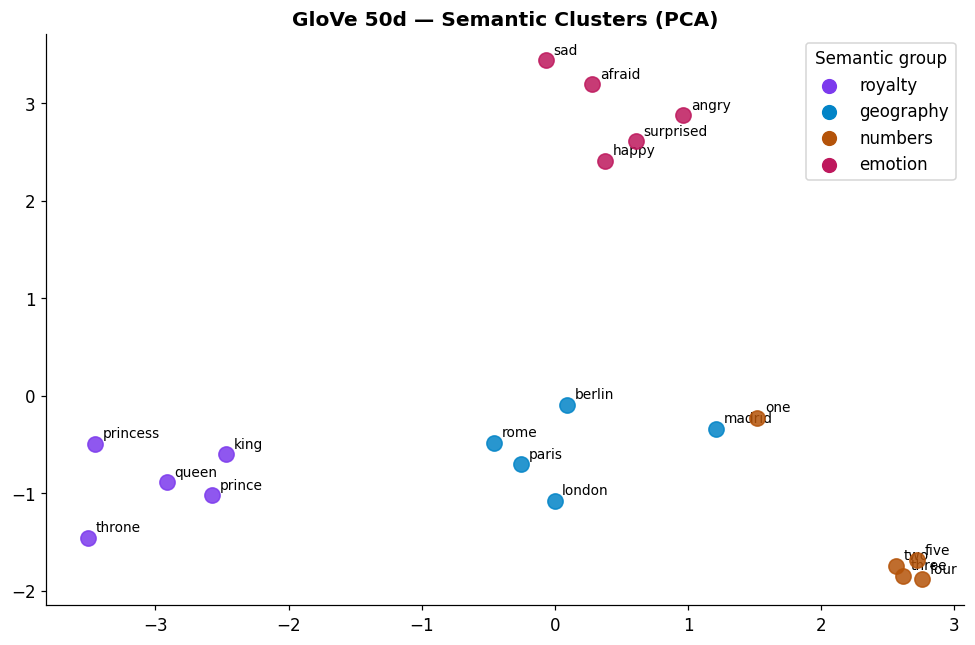

In [23]:
# ── Semantic clusters in GloVe (PCA) ─────────────────────────────────────────
from sklearn.decomposition import PCA

glove_groups = {
    'royalty':   ['king','queen','prince','princess','throne'],
    'geography': ['paris','london','berlin','madrid','rome'],
    'numbers':   ['one','two','three','four','five'],
    'emotion':   ['happy','sad','angry','afraid','surprised'],
}

gw, gl = [], []
for grp, ws in glove_groups.items():
    for w in ws:
        if w in glove:
            gw.append(w); gl.append(grp)

vecs_g = np.array([glove[w] for w in gw])
coords_g = PCA(n_components=2, random_state=42).fit_transform(vecs_g)

cmap_g = {'royalty':'#7c3aed','geography':'#0284c7',
           'numbers':'#b45309','emotion':'#be185d'}
fig, ax = plt.subplots(figsize=(9, 6))
for word, (px, py), lbl in zip(gw, coords_g, gl):
    ax.scatter(px, py, color=cmap_g[lbl], s=100, alpha=0.85, zorder=3)
    ax.annotate(word, (px, py), xytext=(5,4),
                textcoords='offset points', fontsize=9)
for lbl, clr in cmap_g.items():
    ax.scatter([], [], color=clr, label=lbl, s=80)
ax.legend(title='Semantic group')
ax.set_title('GloVe 50d — Semantic Clusters (PCA)', fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='s7'></a>
## 7. FastText — Embeddings with Subword Information
### Bojanowski et al., Facebook AI, 2017

**Core innovation**: Word2Vec and GloVe treat each word as an atomic unit.
FastText represents each word as a **bag of character n-grams** plus the
whole word itself.

For the word "playing" with n=3:
$$\text{playing} \rightarrow \{\texttt{<pl, pla, lay, ayi, yin, ing, ng>}, \texttt{<playing>}\}$$

The word vector is the **sum** of all its subword vectors.

**Why this matters:**
1. **OOV words** ("NLPify", "pre-trained"): unseen words get a vector
   from their subword pieces — never zero.
2. **Morphological variants**: "walk", "walks", "walking", "walked" share
   subwords → naturally similar vectors.
3. **Misspellings**: "recieve" shares subwords with "receive" → similar vector.

In [24]:
# ── Subword decomposition (toy illustration) ─────────────────────────────────
def subwords(word: str, n_min=3, n_max=6) -> list:
    """FastText-style subword n-grams with boundary markers."""
    w = f'<{word}>'
    pieces = []
    for n in range(n_min, n_max + 1):
        pieces += [w[i:i+n] for i in range(len(w) - n + 1)]
    return pieces

for word in ['playing', 'natural', 'NLPify', 'pre-trained']:
    subs = subwords(word)
    print(f"  {word:<15} → {subs[:8]}{'...' if len(subs)>8 else ''}")

  playing         → ['<pl', 'pla', 'lay', 'ayi', 'yin', 'ing', 'ng>', '<pla']...
  natural         → ['<na', 'nat', 'atu', 'tur', 'ura', 'ral', 'al>', '<nat']...
  NLPify          → ['<NL', 'NLP', 'LPi', 'Pif', 'ify', 'fy>', '<NLP', 'NLPi']...
  pre-trained     → ['<pr', 'pre', 're-', 'e-t', '-tr', 'tra', 'rai', 'ain']...


In [25]:
from gensim.models import FastText
from gensim.models.callbacks import CallbackAny2Vec
import time

class EpochProgressFT(CallbackAny2Vec):
    """Epoch progress bar for FastText (no compute_loss support)."""
    def __init__(self, total_epochs):
        self.epoch   = 0
        self.total   = total_epochs
        self.t_start = None

    def on_train_begin(self, model):
        self.t_start = time.time()
        print("  Epoch   Elapsed  Progress")
        print("-" * 50)

    def on_epoch_end(self, model):
        self.epoch += 1
        ela  = time.time() - self.t_start
        pct  = self.epoch / self.total
        fill = int(pct * 30)
        bar  = "\u2588" * fill + "\u2591" * (30 - fill)
        print(f"  {self.epoch:2d}/{self.total}  {ela:>6.1f}s  [{bar}] {pct:.0%}")

EPOCHS = 10
n_tokens = sum(len(s) for s in sentences)
print(f"Training FastText on {len(sentences):,} documents "
      f"({n_tokens:,} tokens) - {EPOCHS} epochs")
print()

ft = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    epochs=EPOCHS,
    seed=42,
    word_ngrams=1,
    callbacks=[EpochProgressFT(EPOCHS)],
)
print(f"\nDone.  Vocabulary: {len(ft.wv):,} words")


Training FastText on 2,000 documents (1,583,820 tokens) - 10 epochs

  Epoch   Elapsed  Progress
--------------------------------------------------
   1/10     7.3s  [███░░░░░░░░░░░░░░░░░░░░░░░░░░░] 10%
   2/10    14.6s  [██████░░░░░░░░░░░░░░░░░░░░░░░░] 20%
   3/10    21.4s  [█████████░░░░░░░░░░░░░░░░░░░░░] 30%
   4/10    28.6s  [████████████░░░░░░░░░░░░░░░░░░] 40%
   5/10    35.4s  [███████████████░░░░░░░░░░░░░░░] 50%
   6/10    42.3s  [██████████████████░░░░░░░░░░░░] 60%
   7/10    49.1s  [█████████████████████░░░░░░░░░] 70%
   8/10    56.4s  [████████████████████████░░░░░░] 80%
   9/10    63.2s  [███████████████████████████░░░] 90%
  10/10    70.2s  [██████████████████████████████] 100%

Done.  Vocabulary: 14,794 words


In [26]:
# ── OOV handling comparison ────────────────────────────────────────────────────
oov_words = ['cinematographer', 'overacted', 'emotionally', 'filmmaking', 'unusually']

print("OOV Word Handling Comparison")
print(f"{'Word':<20} {'In W2V?':<10} {'In FastText?':<14} FT Vector norm")
print("-" * 60)
for word in oov_words:
    in_w2v = word in w2v.wv
    in_ft  = word in ft.wv
    ft_norm = f"{np.linalg.norm(ft.wv[word]):.4f}"
    print(f"  {word:<18} {'✓' if in_w2v else '✗':<10} {'✓' if in_ft else '✗ (subword)':<14} {ft_norm}")

print()
print("FastText ALWAYS produces a vector — even for unseen words.")
print("Word2Vec returns KeyError for OOV words.")

OOV Word Handling Comparison
Word                 In W2V?    In FastText?   FT Vector norm
------------------------------------------------------------
  cinematographer    ✓          ✓              3.4691
  overacted          ✓          ✓              2.7194
  emotionally        ✓          ✓              2.9030
  filmmaking         ✓          ✓              2.5880
  unusually          ✓          ✓              2.2347

FastText ALWAYS produces a vector — even for unseen words.
Word2Vec returns KeyError for OOV words.


In [27]:
# ── FastText vs Word2Vec similarity on shared vocabulary ─────────────────────
shared = [w for w in ['good', 'bad', 'film', 'story', 'actor', 'boring']
          if w in w2v.wv and w in ft.wv]

print("Cosine similarity comparison (Word2Vec vs FastText):")
print(f"{'Word pair':<25} {'W2V':<8} {'FastText'}")
print("-" * 45)
for i, w1 in enumerate(shared):
    for w2 in shared[i+1:]:
        s_w = w2v.wv.similarity(w1, w2)
        s_f = ft.wv.similarity(w1, w2)
        print(f"  {w1+'-'+w2:<23} {s_w:<8.4f} {s_f:.4f}")

Cosine similarity comparison (Word2Vec vs FastText):
Word pair                 W2V      FastText
---------------------------------------------
  good-bad                0.6745   0.6540
  good-film               0.3462   0.3419
  good-story              0.2240   0.2373
  good-actor              0.2508   0.2752
  good-boring             0.3336   0.3287
  bad-film                0.2882   0.2547
  bad-story               0.2198   0.1492
  bad-actor               0.2181   0.2688
  bad-boring              0.4885   0.4057
  film-story              0.5622   0.5609
  film-actor              0.3929   0.3410
  film-boring             0.3531   0.3745
  story-actor             0.1266   0.1892
  story-boring            0.2591   0.3561
  actor-boring            0.2603   0.2982


---
<a id='s8'></a>
## 8. Document-Level Embeddings via Vector Averaging

Word2Vec, GloVe, and FastText produce **word-level** vectors. For document
classification we need a **single fixed-size vector per document**.

The simplest approach: **mean pooling** — average all token embeddings.

$$\mathbf{v}_{\text{doc}} = \frac{1}{|d|} \sum_{w \in d} \mathbf{e}_w$$

This ignores word order and importance weights, but is surprisingly effective
for sentiment and topic classification tasks.

In [28]:
def doc_vector(tokens: list, model, dim: int = 100) -> np.ndarray:
    """Mean-pool word vectors; skip OOV words for Word2Vec."""
    vecs = []
    for w in tokens:
        if hasattr(model.wv, '__contains__'):
            if w in model.wv:
                vecs.append(model.wv[w])
        else:  # gensim KeyedVectors
            try:
                vecs.append(model[w])
            except KeyError:
                pass
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Build document matrix for movie reviews
print("Building document vectors via mean-pooling...")
X_w2v = np.array([doc_vector(list(movie_reviews.words(fid)), w2v)
                   for fid in movie_reviews.fileids()])
print(f"Shape: {X_w2v.shape}  (2000 docs × 100 dims)")

Building document vectors via mean-pooling...
Shape: (2000, 100)  (2000 docs × 100 dims)


### 8.1 Mean Pooling — Step-by-Step Numerical Example

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0">
<b>Sentence: "cat sat mat"</b> with 3-dimensional toy embeddings:
<ol style="margin:6px 0 0 0">
<li><b>Lookup</b>: cat=[0.6, 0.1, -0.3], sat=[0.2, 0.8, 0.5], mat=[0.5, 0.2, -0.1]</li>
<li><b>Sum</b> element-wise: [1.3, 1.1, 0.1]</li>
<li><b>Divide by 3</b>: doc vector = [0.43, 0.37, 0.03]</li>
</ol>
Then we add "not"=[-0.6, -0.1, 0.3] and show that dimension 1 drops (0.43→0.28)
but does not flip — a linear classifier cannot reliably detect negation from the average.
</div>

Mean Pooling -- Numerical Walkthrough

Step 1  Lookup word vectors:
  Word      dim1    dim2    dim3
  ----------------------------
  cat       0.60    0.10   -0.30
  sat       0.20    0.80    0.50
  mat       0.50    0.20   -0.10

Step 2  Element-wise sum = [1.30, 1.10, 0.10]

Step 3  Divide by 3: [0.4333, 0.3667, 0.0333]
        doc vector = [0.43, 0.37, 0.03]

Negation Problem: adding 'not'

'not' vector  = [-0.6 -0.1  0.3]
doc BEFORE 'not'  = [0.4333, 0.3667, 0.0333]
doc AFTER  'not'  = [0.1750, 0.2500, 0.1000]
Change per dim    = [-0.2583 -0.1167  0.0667]
-> 'not' shifts the vector but does NOT flip it.
   A classifier cannot distinguish 'cat sat mat' from 'not cat sat mat'.


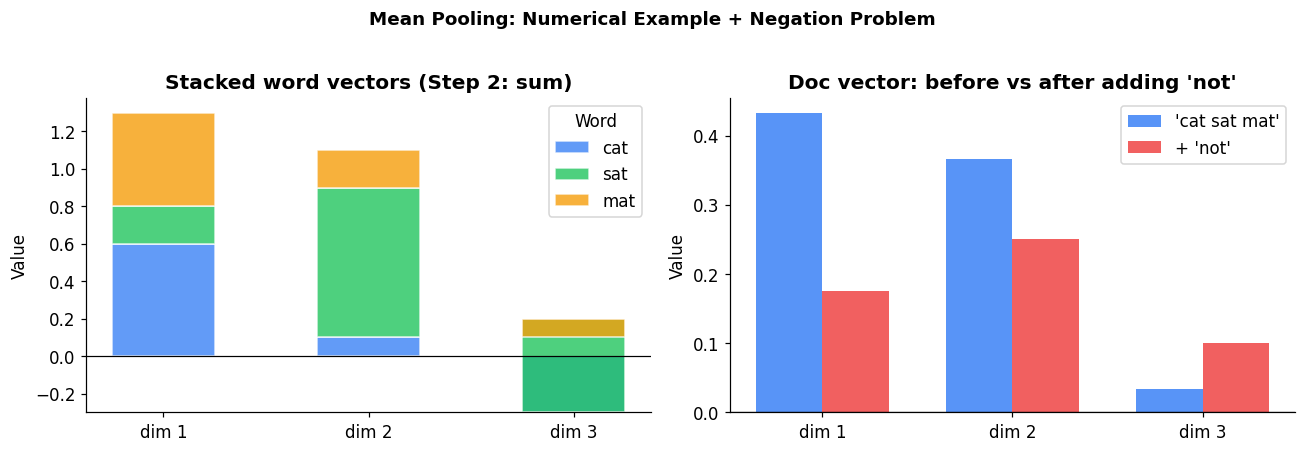

In [29]:
# Mean Pooling: step-by-step numerical example + negation problem
import numpy as np
import matplotlib.pyplot as plt

toy_emb = {
    "cat": np.array([ 0.6,  0.1, -0.3]),
    "sat": np.array([ 0.2,  0.8,  0.5]),
    "mat": np.array([ 0.5,  0.2, -0.1]),
    "not": np.array([-0.6, -0.1,  0.3]),
}

sent_before = ["cat", "sat", "mat"]
sent_after  = ["cat", "sat", "mat", "not"]

print("=" * 55)
print("Mean Pooling -- Numerical Walkthrough")
print("=" * 55)

# Step 1 -- Lookup
print("\nStep 1  Lookup word vectors:")
print(f"  {'Word':6s}  {'dim1':>6}  {'dim2':>6}  {'dim3':>6}")
print("  " + "-" * 28)
for w in sent_before:
    v = toy_emb[w]
    print(f"  {w:6s}  {v[0]:>6.2f}  {v[1]:>6.2f}  {v[2]:>6.2f}")

# Step 2 -- Sum
vecs_b  = np.array([toy_emb[w] for w in sent_before])
vec_sum = vecs_b.sum(axis=0)
print(f"\nStep 2  Element-wise sum = [{vec_sum[0]:.2f}, {vec_sum[1]:.2f}, {vec_sum[2]:.2f}]")

# Step 3 -- Divide
n_b       = len(sent_before)
doc_vec_b = vec_sum / n_b
print(f"\nStep 3  Divide by {n_b}: [{doc_vec_b[0]:.4f}, {doc_vec_b[1]:.4f}, {doc_vec_b[2]:.4f}]")
print(f"        doc vector = [{doc_vec_b[0]:.2f}, {doc_vec_b[1]:.2f}, {doc_vec_b[2]:.2f}]")

# Negation problem
print("\n" + "=" * 55)
print("Negation Problem: adding 'not'")
print("=" * 55)
vecs_a    = np.array([toy_emb[w] for w in sent_after])
doc_vec_a = vecs_a.mean(axis=0)
not_vec   = toy_emb["not"]
print(f"\n'not' vector  = {not_vec}")
print(f"doc BEFORE 'not'  = [{doc_vec_b[0]:.4f}, {doc_vec_b[1]:.4f}, {doc_vec_b[2]:.4f}]")
print(f"doc AFTER  'not'  = [{doc_vec_a[0]:.4f}, {doc_vec_a[1]:.4f}, {doc_vec_a[2]:.4f}]")
delta = doc_vec_a - doc_vec_b
print(f"Change per dim    = {delta.round(4)}")
print("-> 'not' shifts the vector but does NOT flip it.")
print("   A classifier cannot distinguish 'cat sat mat' from 'not cat sat mat'.")

# Bar chart
dims  = ["dim 1", "dim 2", "dim 3"]
x     = np.arange(len(dims))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: stacked word vectors (shows sum)
colours = ["#3b82f6", "#22c55e", "#f59e0b"]
bottom  = np.zeros(3)
for word, clr in zip(sent_before, colours):
    v = toy_emb[word]
    axes[0].bar(x, v, width=0.5, bottom=bottom, label=word,
                color=clr, alpha=0.8, edgecolor="white")
    bottom += v
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(dims)
axes[0].set_title("Stacked word vectors (Step 2: sum)", fontweight="bold")
axes[0].legend(title="Word", loc="upper right")
axes[0].set_ylabel("Value")

# Panel 2: doc vector before vs after "not"
axes[1].bar(x - width/2, doc_vec_b, width, label="'cat sat mat'",
            color="#3b82f6", alpha=0.85)
axes[1].bar(x + width/2, doc_vec_a, width, label="+ 'not'",
            color="#ef4444", alpha=0.85)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(dims)
axes[1].set_title("Doc vector: before vs after adding 'not'", fontweight="bold")
axes[1].legend()
axes[1].set_ylabel("Value")

plt.suptitle("Mean Pooling: Numerical Example + Negation Problem",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr_emb = LogisticRegression(C=1, max_iter=500, solver='saga', n_jobs=-1)
cv_emb = cross_val_score(lr_emb, X_w2v, y, cv=5, scoring='accuracy')
print(f"Mean-pooled Word2Vec + LR  accuracy: {cv_emb.mean():.4f} ± {cv_emb.std():.4f}")
print()
print("Compare with TF-IDF + LR from Section 3:")
print(f"  TF-IDF  : {cv_scores.mean():.4f}")
print(f"  W2V avg : {cv_emb.mean():.4f}")
print()
print("TF-IDF often wins on short/medium corpora because the discriminating")
print("keyword signal is preserved; averaging dilutes it into the sentence vector.")

Mean-pooled Word2Vec + LR  accuracy: 0.7310 ± 0.0190

Compare with TF-IDF + LR from Section 3:
  TF-IDF  : 0.8780
  W2V avg : 0.7310

TF-IDF often wins on short/medium corpora because the discriminating
keyword signal is preserved; averaging dilutes it into the sentence vector.


<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0"><b>💡 Key Insight</b><br>Vector averaging <b>destroys word order</b> and <b>dilutes rare important words</b> —
"not good" averages to something between 'not' and 'good', confusing the classifier.
More sophisticated document encoders (Doc2Vec, BERT [CLS], sentence transformers)
fix this but require more compute.</div>

---
<a id='s9'></a>
## 9. Keras Embedding Layer

In deep learning pipelines, the embedding lookup is a **trainable layer**:
- Input: integer token IDs (indices into vocabulary)
- Output: dense vectors (either random-initialised or pre-loaded)

The embedding layer is the bridge between raw text and neural networks.
Pre-loading GloVe weights and freezing them (`trainable=False`) gives a
strong initialisation that helps on small datasets.

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10_000
MAX_LEN   = 200   # max tokens per review

# Tokenize
tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tok.fit_on_texts(mr_corpus)

X_seq = tok.texts_to_sequences(mr_corpus)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size  : {min(len(tok.word_index), MAX_VOCAB):,}")
print(f"Padded matrix    : {X_pad.shape}")
print(f"Sample (D1, first 20): {X_pad[0, :20]}")

Vocabulary size  : 10,000
Padded matrix    : (2000, 200)
Sample (D1, first 20): [ 100   79  944 4371  133    6    3 2003  788 3795    4  106 1320   37
   76   60   29 1330   27    5]


In [32]:
# Build GloVe embedding matrix for Keras
EMBED_DIM = 50   # match glove-wiki-gigaword-50

embedding_matrix = np.zeros((MAX_VOCAB + 1, EMBED_DIM))
found = 0
for word, idx in tok.word_index.items():
    if idx < MAX_VOCAB + 1 and word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1

coverage = found / min(len(tok.word_index), MAX_VOCAB)
print(f"GloVe coverage of top-{MAX_VOCAB} vocab: {coverage:.1%}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

GloVe coverage of top-10000 vocab: 99.8%
Embedding matrix shape: (10001, 50)


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(MAX_VOCAB + 1, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),         # freeze GloVe weights
    GlobalAveragePooling1D(),           # mean-pool token embeddings
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,050 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,050 (1.91 MB)

In [34]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y)

es = EarlyStopping(monitor='val_accuracy', patience=4,
                   restore_best_weights=True, verbose=1)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[es],
    verbose=1,
)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5181 - loss: 0.7547 - val_accuracy: 0.5000 - val_loss: 0.6953
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5481 - loss: 0.7262 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5875 - loss: 0.6918 - val_accuracy: 0.5025 - val_loss: 0.6929
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5869 - loss: 0.6846 - val_accuracy: 0.5050 - val_loss: 0.6915
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6025 - loss: 0.6681 - val_accuracy: 0.5150 - val_loss: 0.6885
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6069 - loss: 0.6657 - val_accuracy: 0.5150 - val_loss: 0.6875
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6056 - loss: 0.6615 - val_accuracy: 0.5675 - val_loss: 0.6844
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6338 - loss: 0.6511 - val_accuracy: 0.5625 - val_loss

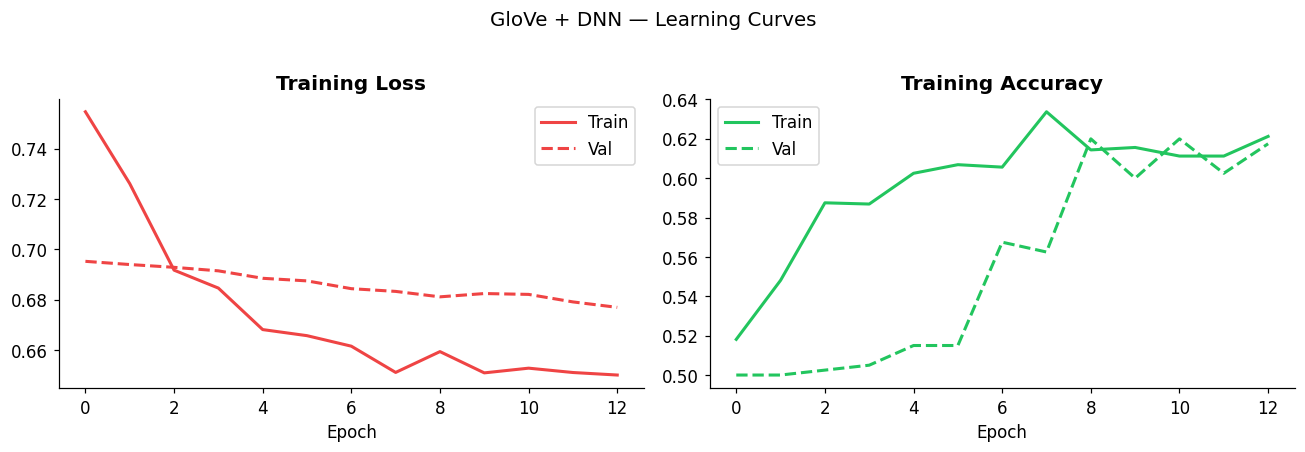

Best validation accuracy: 0.6200


In [35]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, colour in zip(axes, ['loss', 'accuracy'], ['#ef4444', '#22c55e']):
    ax.plot(history.history[metric], label='Train', color=colour, lw=2)
    ax.plot(history.history[f'val_{metric}'], label='Val',
            color=colour, linestyle='--', lw=2)
    ax.set_title(f'Training {metric.capitalize()}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('GloVe + DNN — Learning Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {val_acc:.4f}")

---
<a id='s10'></a>
## 10. Method Comparison & Decision Guide

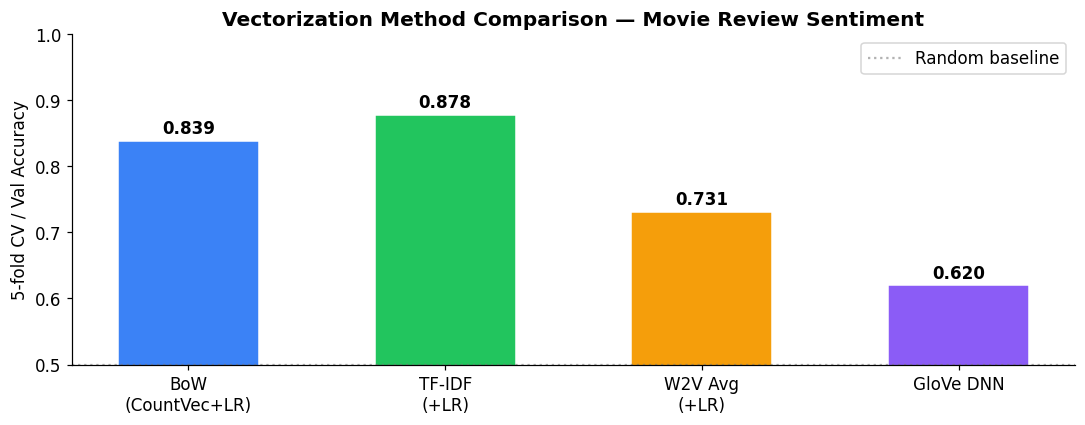

In [36]:
# Collect all accuracy estimates
results = {
    'BoW\n(CountVec+LR)':       None,   # will estimate
    'TF-IDF\n(+LR)':           cv_scores.mean(),
    'W2V Avg\n(+LR)':          cv_emb.mean(),
    'GloVe DNN':                val_acc,
}

# Quick BoW LR benchmark
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
lr_bow = LogisticRegression(C=5, max_iter=500, solver='saga', n_jobs=-1)
bow_cv = cross_val_score(lr_bow, X_bow, y, cv=5, scoring='accuracy')
results['BoW\n(CountVec+LR)'] = bow_cv.mean()

fig, ax = plt.subplots(figsize=(10, 4))
methods = list(results.keys())
scores  = [results[m] for m in methods]
colours = ['#3b82f6','#22c55e','#f59e0b','#8b5cf6']

bars = ax.bar(methods, scores, color=colours, edgecolor='white', width=0.55)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('5-fold CV / Val Accuracy')
ax.set_title('Vectorization Method Comparison — Movie Review Sentiment',
             fontweight='bold')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='Random baseline')
ax.legend()

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Decision Guide

| Scenario | Recommended Method |
|---|---|
| Keyword search, small dataset, interpretability needed | **TF-IDF** |
| Medium dataset, want semantic similarity | **TF-IDF** or **W2V mean-pool** |
| Rare/misspelled words, morphologically rich language | **FastText** |
| Transfer learning from large corpus | **Pre-trained GloVe/W2V** |
| End-to-end trainable with labelled data | **Keras Embedding** (trainable) |
| SotA on classification / NER / QA | **BERT / RoBERTa** (Session 4) |

### Common Pitfalls

| Pitfall | Fix |
|---|---|
| Treating OOV words as zeros in W2V | Use FastText or filter tokens |
| Using TF-IDF on very long documents | Apply `sublinear_tf=True` |
| Not normalising vectors before cosine similarity | Use `Normalizer` or `norm='l2'` |
| Training W2V on <1M tokens | Use pre-trained vectors instead |
| Leaking test vocabulary into CountVectorizer fit | Fit only on **train** split |

---
<a id='s11'></a>
## 11. Exercises

### Part A — In-class Exercises

---
#### Q1. BoW vs TF-IDF on BBC News  (25 min)

**Task:** Load the BBC dataset, build BoW and TF-IDF representations, train
a Logistic Regression classifier for each, compare 5-fold CV accuracy, and
identify the 5 most discriminative TF-IDF terms for each category.

**Bonus:** Plot a bar chart comparing category-level F1 scores for both methods.

In [37]:
# Q1 — BoW vs TF-IDF on BBC News
# YOUR CODE HERE

import pathlib

# Colab: upload bbc-text.csv via the file panel, or run:
# from google.colab import files; files.upload()

bbc_path = None
for candidate in [
    pathlib.Path('bbc-text.csv'),
    pathlib.Path('../../data/bbc-text.csv'),
    pathlib.Path('../data/bbc-text.csv'),
]:
    if candidate.exists():
        bbc_path = candidate
        break

if bbc_path:
    df_bbc = pd.read_csv(bbc_path)
    print(df_bbc.head(3))
    print(df_bbc['category'].value_counts())
else:
    print("Upload bbc-text.csv to continue.")

Upload bbc-text.csv to continue.


---
#### Q2. Word2Vec Analogies & Semantic Arithmetic  (20 min)

**Task:** Using the Word2Vec model trained in Section 5:
1. Find the 10 words most similar to `'plot'`, `'actor'`, `'scene'`
2. Compute 3 analogies using `most_similar(positive=[...], negative=[...])`
3. Are the results semantically reasonable? Explain why or why not.

In [38]:
# Q2 — Word2Vec Analogies
# YOUR CODE HERE

# Hint: use w2v.wv.most_similar() and w2v.wv.doesnt_match()
# Example:  w2v.wv.most_similar(positive=['film', 'love'], negative=['hate'], topn=5)

---
#### Q3. OOV Handling with FastText  (20 min)

**Task:**
1. Create a list of 10 domain-specific or morphologically complex words
   (e.g., "overacting", "cinematographic", "storyline")
2. For each word, check if it's in the Word2Vec vocabulary and in FastText
3. For OOV words in FastText, find their 5 nearest in-vocabulary neighbours
4. Explain how FastText constructs the OOV vector

In [39]:
# Q3 — OOV Handling
# YOUR CODE HERE
test_words = ['overacting', 'cinematographic', 'storyline', 'pre-trained',
              'emotionally', 'directorial', 'filmmaking', 'watchable',
              'unpredictable', 'reimagined']

# For each word: check in w2v.wv, check in ft.wv, find nearest neighbours

---
### Part B — Take-Home Exercises

---
#### B1. Custom Text Vectorization Pipeline  (45 min)

Build a reusable `TextVectorizer` class that:
- Accepts a `method` parameter: `'bow'`, `'tfidf'`, `'w2v_avg'`, `'ft_avg'`
- Exposes `fit(corpus)`, `transform(corpus)`, `fit_transform(corpus)`
- Uses appropriate sklearn / gensim internals
- Handles OOV words gracefully for embedding methods

Evaluate it on the movie_reviews corpus with each method and produce a
comparison plot.

In [40]:
# B1 — TextVectorizer class
# YOUR CODE HERE

class TextVectorizer:
    def __init__(self, method: str = 'tfidf', dim: int = 100):
        """
        Args:
            method: one of 'bow', 'tfidf', 'w2v_avg', 'ft_avg'
            dim: embedding dimension (used for w2v/ft methods)
        """
        self.method = method
        self.dim = dim
        self.model_ = None

    def fit(self, corpus: list) -> 'TextVectorizer':
        # YOUR CODE HERE
        raise NotImplementedError

    def transform(self, corpus: list):
        # YOUR CODE HERE
        raise NotImplementedError

    def fit_transform(self, corpus: list):
        return self.fit(corpus).transform(corpus)

---
#### B2. GloVe vs Word2Vec — Qualitative Analysis  (30 min)

1. Load `glove-wiki-gigaword-50` (already loaded as `glove`)
2. For a list of 20 diverse words (emotions, countries, professions, sports),
   compute the embedding from both GloVe and Word2Vec
3. Plot t-SNE projections of both embeddings side-by-side
4. Which method produces tighter semantic clusters? Measure quantitatively
   using mean intra-cluster cosine similarity.

In [41]:
# B2 — GloVe vs Word2Vec t-SNE
# YOUR CODE HERE

from sklearn.manifold import TSNE

word_groups = {
    'emotions':    ['happy', 'sad', 'angry', 'afraid', 'surprised', 'disgusted'],
    'countries':   ['france', 'germany', 'japan', 'india', 'brazil', 'egypt'],
    'professions': ['doctor', 'teacher', 'engineer', 'lawyer', 'nurse', 'pilot'],
    'sports':      ['football', 'tennis', 'swimming', 'cricket', 'boxing', 'golf'],
}

# Hint: filter words present in BOTH models, stack vectors,
#       run TSNE(n_components=2, random_state=42),
#       plot with group colours and compute intra-cluster mean cosine similarity

---
#### B3. Sentiment Classification with All Methods  (60 min)

Build an end-to-end benchmark comparing:
- BoW + Naive Bayes
- TF-IDF + Logistic Regression
- Word2Vec mean-pool + SVM
- FastText mean-pool + SVM
- GloVe DNN (pre-loaded Keras embedding)

Use `stratified_kfold(n_splits=5)` and report mean ± std accuracy and F1
for each. Plot results as a grouped bar chart with error bars.

In [42]:
# B3 — Full Benchmark
# YOUR CODE HERE
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_b3 = {}

# Implement each method's fit/transform cycle inside the CV loop
# Then collect accuracies and plot

---
## Session Summary

| Section | Method | Key hyperparameter | Typical accuracy (movie reviews) |
|---|---|---|---|
| 2 | Bag of Words | `max_features`, `min_df` | 75–80% |
| 3 | TF-IDF | `sublinear_tf`, `ngram_range` | 80–85% |
| 5 | Word2Vec (avg) | `vector_size`, `window`, `sg` | 75–82% |
| 6 | GloVe (avg) | `dim=50/100/300` | 78–84% |
| 7 | FastText (avg) | `word_ngrams`, `min_count` | 78–83% |
| 9 | GloVe + DNN | `MAX_LEN`, `Dropout`, `patience` | 82–87% |

**Key lessons learned:**

1. **Sparsity vs semantics**: TF-IDF is interpretable and fast; embeddings capture meaning but need volume.
2. **OOV**: FastText handles unseen words via character subwords; W2V and GloVe cannot.
3. **Averaging dilutes**: Mean pooling loses word order; better encoders (Attention, BERT) fix this.
4. **Pre-trained beats trained-from-scratch** on small corpora — always try pre-trained GloVe/FastText first.
5. **Evaluation discipline**: always fit vectorizers on **train** data only; transform test data.

**Next session:** Sequence-to-Sequence models — Encoder-Decoder architecture, Attention mechanism, Neural Machine Translation.